In [11]:
# !pip install dotenv

In [12]:
import pandas as pd
import numpy as np
from pymongo import MongoClient

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv




In [13]:
load_dotenv()

print("USER:", os.getenv("MONGO_USER"))
print("PASS:", os.getenv("MONGO_PASS"))
print("CLUSTER:", os.getenv("MONGO_CLUSTER"))


USER: iveymistele
PASS: Frostyccino1
CLUSTER: cluster0.93xer.mongodb.net


In [14]:
# Prep data
from pymongo import MongoClient
import pandas as pd

# Config
MONGO_PASS = os.getenv('MONGO_PASS')
MONGO_USER = "iveymistele"
MONGO_CLUSTER = "cluster0.93xer.mongodb.net"

MONGO_URI = f"mongodb+srv://{MONGO_USER}:{MONGO_PASS}@{MONGO_CLUSTER}/?retryWrites=true&w=majority"


In [15]:
client = MongoClient(MONGO_URI)
db = client["epstein_db"]
collection = db["emails"]

data = list(collection.find({}))
df = pd.DataFrame(data)

# basic cleaning
#df = df.dropna(subset=["from", "to", "body"])

In [16]:
print(df.columns.tolist())

['_id', 'document_id', 'email_text', 'source_file', 'is_email', 'participants', 'date', 'time', 'subject', 'has_attachments', 'attachment_names', 'people_mentioned', 'organizations', 'locations', 'phone_numbers', 'urls', 'notable_figures', 'primary_topic', 'topics', 'inferred_people', 'summary', 'key_quotes', 'tone', 'potential_crimes', 'evidence_strength', 'crime_types', 'mentions_victims', 'victim_names', 'cover_up', 'timestamp', 'participant_names', 'participant_emails', 'participant_count', 'attachment_count', 'url_count']


In [17]:
import pandas as pd

df = df.copy()

# keep columns most useful for analysis
df = df[
    [
        "_id",
        "document_id",
        "email_text",
        "subject",
        "date",
        "participant_names",
        "participant_emails",
        "participant_count",
        "people_mentioned",
        "organizations",
        "locations",
        "topics",
        "primary_topic",
        "tone",
        "evidence_strength",
        "crime_types",
        "mentions_victims",
        "victim_names",
        "attachment_count",
        "url_count"
    ]
].copy()

# clean text
df["email_text"] = df["email_text"].fillna("").astype(str).str.strip()
df["subject"] = df["subject"].fillna("").astype(str).str.strip()
df["primary_topic"] = df["primary_topic"].fillna("Unknown").astype(str).str.strip()
df["tone"] = df["tone"].fillna("Unknown").astype(str).str.strip()

# remove empty emails
df = df[df["email_text"] != ""].copy()

print(df.shape)
df.head()

(2322, 20)


,_id,document_id,email_text,subject,date,participant_names,participant_emails,participant_count,people_mentioned,organizations,locations,topics,primary_topic,tone,evidence_strength,crime_types,mentions_victims,victim_names,attachment_count,url_count
0,HOUSE_OVERSIGHT_011277,HOUSE_OVERSIGHT_011277,"From: Ens, Amand \nSent: 12/9/2016 3:46:19 PM ...",RE: Financials: buy XLF call spreads,2016-12-09,"[Amand Ens, Jeffrey Epstein, Rich Kahn]","[amand.ens@bofa.com, jeeyacation@gmail.com]",3,"[Amanda Ens, Rich Kahn, Erika Najarian, Nigel ...","[Bank of America Merrill Lynch, Merrill Lynch ...","[New York, NY, One Bryant Park]","[financial, business]",financial,routine,none,[],False,[],1,1
1,HOUSE_OVERSIGHT_011280,HOUSE_OVERSIGHT_011280,"From: Ens, Amanda_____________________________...",RE: Financials: buy XLF call spreads,2016-12-09,"[Amanda Ens, Jeffrey Epstein, Richard Kah, Ric...",[jeeyacation@gmail.com],4,"[Amanda Ens, Jeffrey Epstein, Richard Kahn, Er...","[Bank of America Merrill Lynch, Merrill Lynch,...","[New York, NY, North America, United States]","[financial, business]",financial,routine,none,[],False,[],1,1
2,HOUSE_OVERSIGHT_011904,HOUSE_OVERSIGHT_011904,From: Lawrence Krauss \nSent: 4/5/2018 10:16:5...,Re:,2018-04-05,"[Lawrence Krauss, Jeffrey Epstein, Tina Brown]",[jeeyacation@gmail.com],3,"[Lawrence Krauss, Kevin Spacey, Bill Clinton, ...","[The Origins Project at ASU, Arizona State Uni...","[Tempe, AZ]",[social],social,informal,none,[],False,[],1,3
3,HOUSE_OVERSIGHT_011907,HOUSE_OVERSIGHT_011907,From: Nicholas Ribis \nSent: 5/7/2019 1:53:22 ...,RE:,2019-05-07,"[Nicholas Ribis, Jeffrey Epstein]","[nicholasribis@example.com, jeevacation@gmail....",2,"[Nicholas Ribis, Stephanie Winston Wolkoff]",[The New York Times],[],[media_pr],media_pr,guarded,none,[],False,[],0,1
4,HOUSE_OVERSIGHT_012037,HOUSE_OVERSIGHT_012037,From: jeffrey E. [jeeyacation@gmail.com] \nSen...,Re: Press: AmLaw Litigation Daily on Emirates ...,2016-08-15,"[Jeffrey Epstein, Kathy Ruemmler, Schecter Dan...",[jeeyacation@gmail.com],21,"[Jeffrey Epstein, Kathy Ruemmler, Daniel Schec...","[Emirates NBD Bank PJSC, Latham & Watkins LLP,...","[Orange County, California, Dubai, UAE, United...","[legal, media_pr, business]",legal,routine,none,[],False,[],0,8


In [18]:
# numeric features
df["email_length"] = df["email_text"].str.len()
df["word_count"] = df["email_text"].str.split().str.len()

df["participant_count"] = pd.to_numeric(df["participant_count"], errors="coerce").fillna(0)
df["attachment_count"] = pd.to_numeric(df["attachment_count"], errors="coerce").fillna(0)
df["url_count"] = pd.to_numeric(df["url_count"], errors="coerce").fillna(0)

df[["email_length", "word_count", "participant_count", "attachment_count", "url_count"]].describe()

,email_length,word_count,participant_count,attachment_count,url_count
count,2322.000000,2322.000000,2322.000000,2322.000000,2322.000000
mean,5122.717054,759.833764,2.903101,0.342808,1.066322
std,12025.839171,2003.695969,2.614809,1.834271,3.316806
min,155.000000,19.000000,1.000000,0.000000,0.000000
25%,1129.750000,165.000000,2.000000,0.000000,0.000000
50%,2386.000000,365.000000,2.000000,0.000000,0.000000
75%,5060.000000,757.750000,3.000000,0.000000,1.000000
max,293645.000000,53724.000000,35.000000,64.000000,69.000000


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    min_df=2
)

X_text = vectorizer.fit_transform(df["email_text"])

print(X_text.shape)

(2322, 500)


In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_text)

df["cluster"].value_counts().sort_index()

cluster
0    1120
1    1091
2     111
Name: count, dtype: int64

In [21]:
cluster_summary = df.groupby("cluster").agg(
    email_count=("email_text", "count"),
    avg_email_length=("email_length", "mean"),
    avg_word_count=("word_count", "mean"),
    avg_participant_count=("participant_count", "mean"),
    avg_attachment_count=("attachment_count", "mean"),
    avg_url_count=("url_count", "mean")
)

cluster_summary

,email_count,avg_email_length,avg_word_count,avg_participant_count,avg_attachment_count,avg_url_count
cluster,,,,,,
0,1120,2999.775893,459.866964,2.356250,0.080357,0.452679
1,1091,7574.321723,1108.177819,3.532539,0.644363,1.655362
2,111,2446.981982,362.711712,2.234234,0.027027,1.468468


In [22]:
terms = vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

for i in range(kmeans.n_clusters):
    top_indices = centers[i].argsort()[::-1][:10]
    top_terms = [terms[j] for j in top_indices]
    print(f"Cluster {i}: {', '.join(top_terms)}")

Cluster 0: communication, thereof, use, mail, information, com, gmail, jeevacation, wrote, jeffrey
Cluster 1: epstein, com, trump, house, jeffrey, oversight, sent, new, subject, pm
Cluster 2: landon, jr, thomas, communication, nytimes, reporter, com, financial, http, people


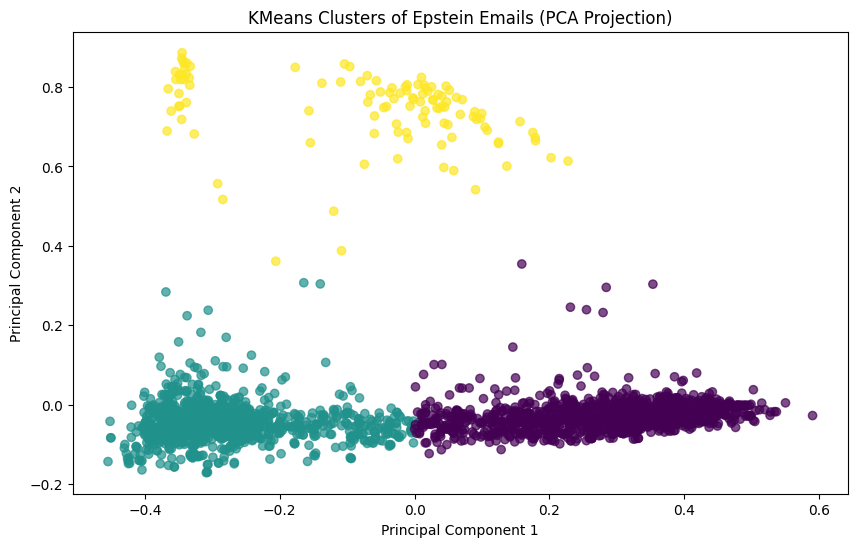

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_dense = X_text.toarray()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], alpha=0.7)
plt.title("KMeans Clusters of Epstein Emails (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

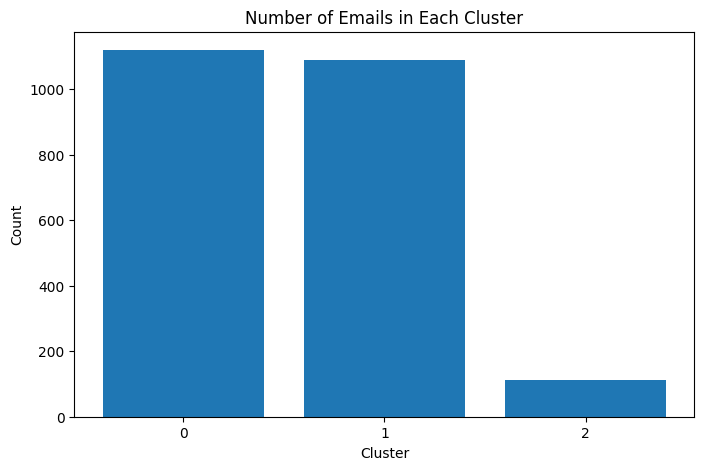

In [24]:
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Number of Emails in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [25]:
for c in sorted(df["cluster"].unique()):
    print(f"\n--- Cluster {c} sample emails ---")
    sample_rows = df[df["cluster"] == c][["subject", "primary_topic", "tone", "email_text"]].head(3)
    
    for _, row in sample_rows.iterrows():
        print("\nSubject:", row["subject"])
        print("Primary topic:", row["primary_topic"])
        print("Tone:", row["tone"])
        print("Email preview:", row["email_text"][:500])
        print("-" * 60)


--- Cluster 0 sample emails ---

Subject: RE:
Primary topic: media_pr
Tone: guarded
Email preview: From: Nicholas Ribis 
Sent: 5/7/2019 1:53:22 PM 
To: 'J Deevacation@gmail.com] 
Subject: RE: 
Importance: High 
More bad news for our friend 
From: J [mailto:jeevacation@gmail.com] 
Sent: Tuesday, May 07, 2019 12:29 AM 
To: Nicholas Ribis < 
Subject: 
https://www.nytimes.com/20 1 9/05/06/us/p olitics/trump -inauguration-step hanie-winston-
wolkoffhtml?action=click&module=Top%20Stories&pgtype=Homepage  
please note 
The information contained in this communication is 
confidential, may be attorney
------------------------------------------------------------

Subject: 
Primary topic: media_pr
Tone: guarded
Email preview: From: J [jeevacation@gmail.com] 
Sent: 5/7/2019 4:29:00 AM 
To: Nicholas Ribis 
https://www.nytimes.com/20 1 9/05/0 6/us/p olitics/trump -inauguration-step hanie-winston-
wolkoff.html?action=click&module=Top%20Stories&pgtype=Homepage  
please note 
The information contained

In [26]:
pd.crosstab(df["cluster"], df["primary_topic"])

primary_topic,business,financial,legal,media_pr,other,personal,political,real_estate,social,travel
cluster,,,,,,,,,,
0,140,80,196,265,33,104,15,12,150,125
1,102,101,254,350,62,23,16,18,118,47
2,15,31,10,44,0,3,0,0,8,0


In [27]:
pd.crosstab(df["cluster"], df["tone"])

tone,guarded,informal,routine,urgent
cluster,,,,
0,323,508,252,37
1,138,300,592,61
2,21,54,34,2


In [28]:
pd.crosstab(df["cluster"], df["evidence_strength"])

evidence_strength,contextual,explicit,none,suspicious
cluster,,,,
0,93,3,988,36
1,183,4,901,3
2,18,0,92,1


# Network Analysis

In [29]:
# !pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
import networkx as nx
import itertools

G = nx.Graph()



for people in df["people_mentioned"]:
    if isinstance(people, list) and len(people) > 1:
        people = list(set(people))  # remove duplicates
        
        for a, b in itertools.combinations(people, 2):
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
            else:
                G.add_edge(a, b, weight=1)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 4503
Edges: 103522


In [34]:
# add node sizes
from collections import Counter

counts = Counter()

def clean_people(people):
    if isinstance(people, list):
        return [p for p in people if len(p.split()) > 1]
    return []

df["people_clean"] = df["people_mentioned"].apply(clean_people)

for people in df["people_clean"]:
    if isinstance(people, list):
        counts.update(people)

for node in G.nodes():
    G.nodes[node]["count"] = counts[node]

In [44]:
# keep top 15 most mentioned people
top_people = set([p for p, _ in counts.most_common(15)])

G_sub = G.subgraph(top_people).copy()

print("Filtered nodes:", G_sub.number_of_nodes())

Filtered nodes: 15


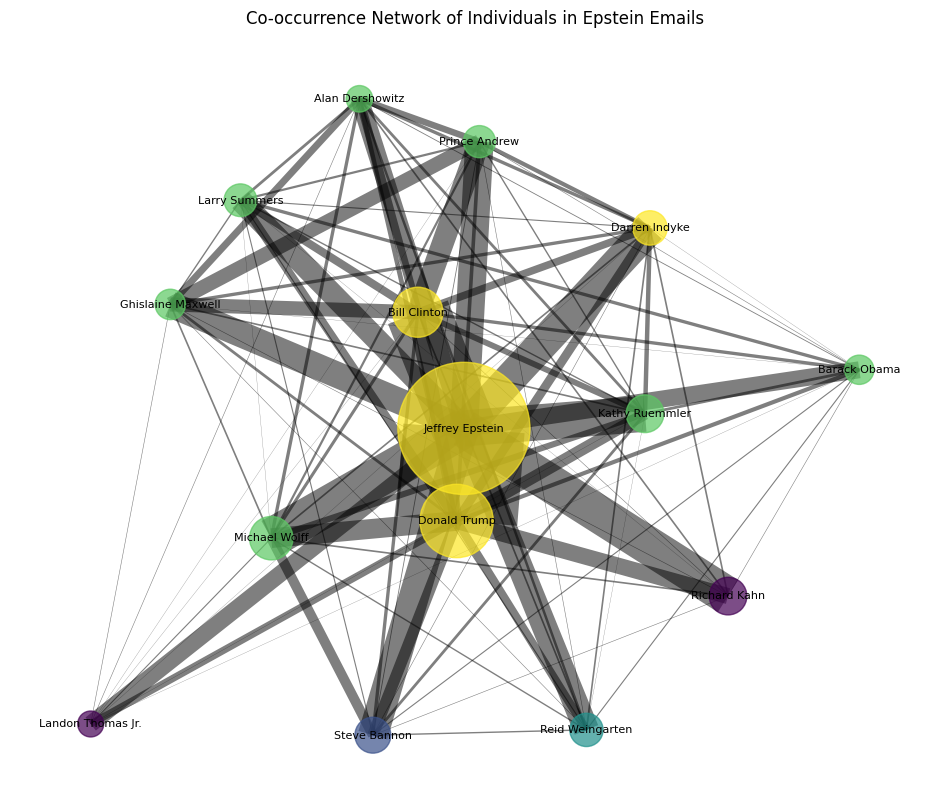

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G_sub, seed=42)

node_sizes = [G_sub.nodes[n]["count"] * 5 for n in G_sub.nodes()]
edge_widths = [G_sub[u][v]["weight"] * 0.2 for u, v in G_sub.edges()]

centrality = nx.degree_centrality(G_sub)

node_colors = [centrality[n] for n in G_sub.nodes()]

nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color=node_colors,
    cmap=plt.cm.viridis,alpha=0.7)
nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.5)
nx.draw_networkx_labels(G_sub, pos, font_size=8)

plt.title("Co-occurrence Network of Individuals in Epstein Emails")
plt.axis("off")
plt.show()